In [1]:
# bibliotecas
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
from sklearn.model_selection import StratifiedKFold

In [3]:
# carregando os dados
(X, y_original), _ = mnist.load_data()
X = X.reshape(X.shape[0], 28, 28, 1).astype('float32') / 255
y = np_utils.to_categorical(y_original, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# configurando o K-Fold
seed = 7
np.random.seed(seed)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

In [6]:
# criando as listas
resultados = []
historicos = []

# começando o loop pra treinar
for fold, (idx_treino, idx_val) in enumerate(kfold.split(X, np.zeros(shape=(y.shape[0], 1)))):

    # montei uma arquitetura com duas camadas de convolução
    classificador = Sequential()
    classificador.add(InputLayer(shape=(28, 28, 1)))

    # usei BatchNormalization pra rede treinar mais rápido e ficar mais estável
    classificador.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    classificador.add(BatchNormalization())
    classificador.add(MaxPooling2D(pool_size=(2, 2)))

    classificador.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    classificador.add(BatchNormalization())
    classificador.add(MaxPooling2D(pool_size=(2, 2)))

    # achatando tudo pra mandar pras camadas densas finais
    classificador.add(Flatten())
    classificador.add(Dense(units=128, activation='relu'))
    classificador.add(Dense(units=10, activation='softmax'))

    classificador.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # treinando o modelo desse fold específico
    hist = classificador.fit(X[idx_treino], y[idx_treino], batch_size=128, epochs=5, verbose=1)
    historicos.append(hist)

    # avaliando a precisão no grupo de validação da vez e guardando o resultado
    precisao = classificador.evaluate(X[idx_val], y[idx_val], verbose=0)
    resultados.append(precisao[1])
    print(f'Acurácia fold {fold+1}: {precisao[1]:.4f}')

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 207ms/step - accuracy: 0.8875 - loss: 0.3950
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 206ms/step - accuracy: 0.9876 - loss: 0.0406
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 75s 201ms/step - accuracy: 0.9925 - loss: 0.0248
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 209ms/step - accuracy: 0.9937 - loss: 0.0178
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 78s 208ms/step - accuracy: 0.9960 - loss: 0.0136
Acurácia fold 1: 0.9888
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 208ms/step - accuracy: 0.9043 - loss: 0.3442
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 208ms/step - accuracy: 0.9866 - loss: 0.0450
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 205ms/step - accuracy: 0.9921 - loss: 0.0241
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 206ms/step - accuracy: 0.9943 - loss: 0.0176
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - accuracy: 0.9947 - loss: 0.0156
Acurácia fold 2: 0.9879
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 205ms/step - accuracy: 0.9010

In [7]:
results = np.array(resultados)
print(f'Média: {results.mean():.4f}  |  Desvio padrão: {results.std():.4f}')

Média: 0.9869  |  Desvio padrão: 0.0018


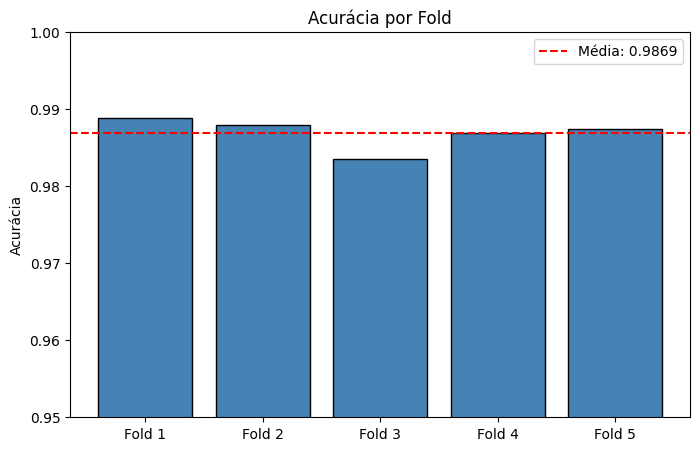

In [8]:
# montando o gráfico pra ver como cada fold se saiu
plt.figure(figsize=(8, 5))

# mostra se o fold usando uma cor diferente
plt.bar([f'Fold {i+1}' for i in range(5)], resultados, color='steelblue', edgecolor='black')

# mostra se fold ficou muito abaixo ou acima do esperado
plt.axhline(results.mean(), color='red', linestyle='--', label=f'Média: {results.mean():.4f}')

# dei um zoom no topo do gráfico 0.95 a 1.0 só pra destacar as pequenas diferenças
plt.ylim(0.95, 1.0)

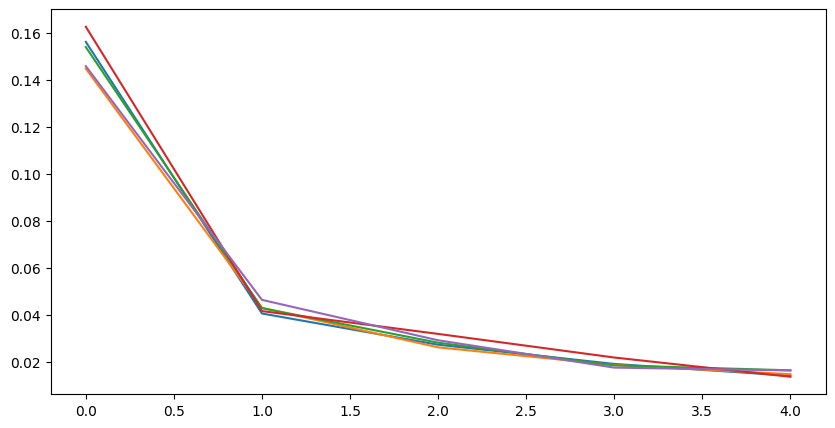

In [10]:
# aqui eu crio um gráfico pra ver como a perda  baixou em cada fold
plt.figure(figsize=(10, 5))

# e ploto as linhas juntas pra comparar se alguma demorou mais pra convergir
for i, hist in enumerate(historicos):
    plt.plot(hist.history['loss'], label=f'Fold {i+1}')